# PNAS Splicing Model — Predictions

Loads `model_weights.pt` and generates PSI predictions for the train and test datasets.

In [1]:
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, '.')  # make model.py importable
from model import PNASModel

## 1. Load model

In [2]:
WEIGHTS_PATH = 'model_weights.pt'
INPUT_LENGTH = 90
BATCH_SIZE   = 512
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

model = PNASModel(input_length=INPUT_LENGTH)
state_dict = torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=False)
# checkpoint may be a raw state dict or nested under 'model_state_dict'
if 'model_state_dict' in state_dict:
    state_dict = state_dict['model_state_dict']
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cpu
Parameters: 9,747


## 2. Load datasets

In [3]:
def load_npz(path):
    d = np.load(path, allow_pickle=True)
    return {
        'seq_oh':   d['seq_oh'],
        'struct_oh': d['struct_oh'],
        'wobbles':  d['wobbles'],
        'psi':      d['metadata_PSI'].astype(np.float32),
        'exon':     d['exon'],
    }

train_data = load_npz('data/train_data.npz')
test_data  = load_npz('data/test_data.npz')

print(f'Train: {len(train_data["psi"]):,} examples')
print(f'Test:  {len(test_data["psi"]):,} examples')

Train: 191,846 examples
Test:  47,962 examples


## 3. Run predictions

In [4]:
@torch.no_grad()
def predict(data, batch_size=BATCH_SIZE):
    dataset = TensorDataset(
        torch.as_tensor(data['seq_oh']),
        torch.as_tensor(data['struct_oh']),
        torch.as_tensor(data['wobbles']),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    for seq, struct, wobble in loader:
        seq    = seq.to(DEVICE)
        struct = struct.to(DEVICE)
        wobble = wobble.to(DEVICE)
        out = model(seq, struct, wobble)  # sigmoid output in (0, 1)
        preds.append(out.cpu())
    return torch.cat(preds).numpy()

train_pred = predict(train_data)
test_pred  = predict(test_data)
print(f'Train pred range: [{train_pred.min():.3f}, {train_pred.max():.3f}]')
print(f'Test  pred range: [{test_pred.min():.3f},  {test_pred.max():.3f}]')

/Users/abr10036/miniforge3/lib/python3.12/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


Train pred range: [0.000, 0.988]
Test  pred range: [0.000,  0.988]


## 4. Evaluate

In [5]:
def metrics(true, pred, label):
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    r, _  = pearsonr(true, pred)
    print(f'{label:6s}  RMSE={rmse:.4f}  Pearson r={r:.4f}  n={len(true):,}')
    return rmse, r

metrics(train_data['psi'], train_pred, 'Train')
metrics(test_data['psi'],  test_pred,  'Test')

Train   RMSE=0.1752  Pearson r=0.9120  n=191,846
Test    RMSE=0.1800  Pearson r=0.9069  n=47,962


(np.float32(0.17999008), np.float32(0.9069369))

## 5. Scatter plot: predicted vs. measured PSI

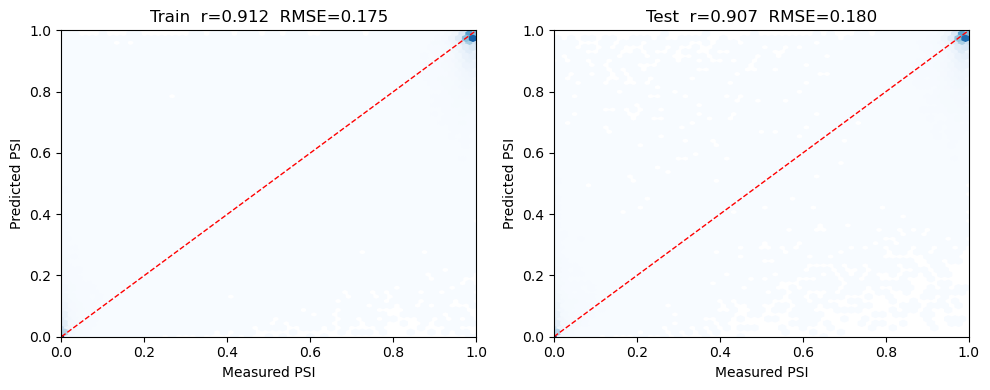

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, true, pred, title in [
    (axes[0], train_data['psi'], train_pred, 'Train'),
    (axes[1], test_data['psi'],  test_pred,  'Test'),
]:
    ax.hexbin(true, pred, gridsize=60, cmap='Blues', mincnt=1)
    ax.plot([0, 1], [0, 1], 'r--', lw=1)
    r, _ = pearsonr(true, pred)
    rmse  = np.sqrt(np.mean((pred - true) ** 2))
    ax.set_title(f'{title}  r={r:.3f}  RMSE={rmse:.3f}')
    ax.set_xlabel('Measured PSI')
    ax.set_ylabel('Predicted PSI')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6. Save predictions

In [7]:
pd.DataFrame({'exon': train_data['exon'], 'psi_measured': train_data['psi'], 'psi_predicted': train_pred}).to_csv('data/predictions_train.csv', index=False)
pd.DataFrame({'exon': test_data['exon'],  'psi_measured': test_data['psi'],  'psi_predicted': test_pred}).to_csv('data/predictions_test.csv', index=False)
print('Saved predictions_train.csv and predictions_test.csv')

Saved predictions_train.csv and predictions_test.csv
